# Etude sur la vente des jeux vidéo.

Ce document retrace les résultats de mes tests. Mais je ne sais plus comment aborder un dataset. Donc il faut apprendre

## 1. Observation des premières lignes du tableau et sélection des éléments importants.

In [33]:
# Import des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/vgchartz-2024.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [34]:
# Nettoyage des données 
df = df.dropna()
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018-11-02
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2018-04-07
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2018-04-07


On prendra les données suivantes :
- le type de ``"console"``, 
- le ``"genre"``, 
- le score : ``"critic_score"``, 
- le nombre total de ventes : ``"total_sales"`` 
- le studio choisi : ``"publisher"``

In [35]:
# Séparation & Nettoyage des données
data = df[["console", "genre", "critic_score", "total_sales", "publisher" ]]
data.head()

,console,genre,critic_score,total_sales,publisher
1,PS4,Action,9.7,19.39,Rockstar Games
4,PS4,Shooter,8.1,15.09,Activision
7,PS4,Action-Adventure,9.8,13.94,Rockstar Games
8,X360,Shooter,8.4,13.86,Activision
9,PS3,Shooter,8.0,13.80,Activision


In [36]:
data.describe()

,critic_score,total_sales
count,282.000000,282.000000
mean,7.659929,1.874149
std,1.203786,2.895821
min,3.000000,0.020000
25%,7.000000,0.370000
50%,7.900000,0.710000
75%,8.500000,1.882500
max,9.800000,19.390000


In [37]:
data["critic_score"].value_counts()

critic_score
8.1    19
8.0    19
7.9    18
7.5    15
8.5    15
8.6    10
7.0    10
8.3     9
9.0     9
7.6     9
8.8     8
8.7     8
8.4     7
6.9     7
9.3     7
7.4     7
8.9     6
7.7     6
6.0     6
9.1     5
6.7     5
6.6     5
9.5     4
7.2     4
5.5     4
8.2     4
6.3     4
5.9     4
7.3     4
7.1     3
9.4     3
6.2     3
6.5     3
5.0     3
4.8     3
9.7     2
6.8     2
5.8     2
9.2     2
5.4     2
6.1     2
7.8     2
5.7     2
9.8     1
3.2     1
5.1     1
5.6     1
5.2     1
3.0     1
5.3     1
4.3     1
4.7     1
4.5     1
Name: count, dtype: int64

In [38]:
data["total_sales"].head()

1    19.39
4    15.09
7    13.94
8    13.86
9    13.80
Name: total_sales, dtype: float64

## 2. Interprétation des données en visuel.

In [39]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

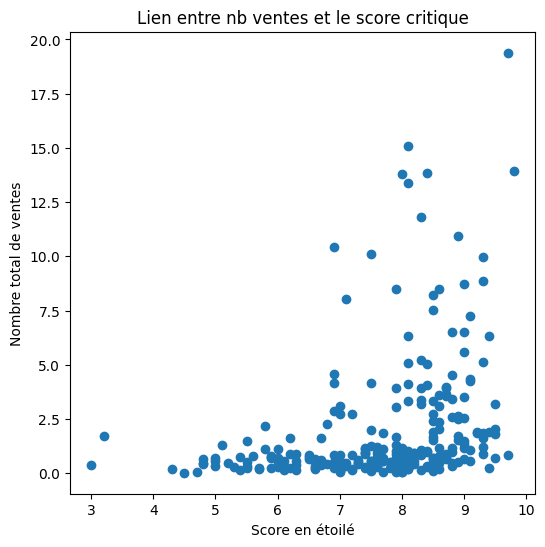

In [ ]:
X = pd.Series(data["critic_score"])
y = pd.Series(data["total_sales"])
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.title("Lien entre nb ventes et le score critique")
plt.xlabel("Score en étoilé")
plt.ylabel("Nombre total de ventes")
plt.show()

## 3. Prédiction des futures ventes en fonction du score étoilé

In [ ]:
from sklearn.linear_model import LinearRegression

In [44]:
X = pd.array(X)
X = X.reshape(282,1)
print(X.shape)

(282, 1)


In [49]:
X.to_numpy(dtype='float', na_value=np.nan)                                 

model = LinearRegression()
model.fit(X, y)
print(f"{model.coef_=}, {model.intercept_=}")

model.coef_=array([0.75991653]), model.intercept_=np.float64(-3.946757804019368)


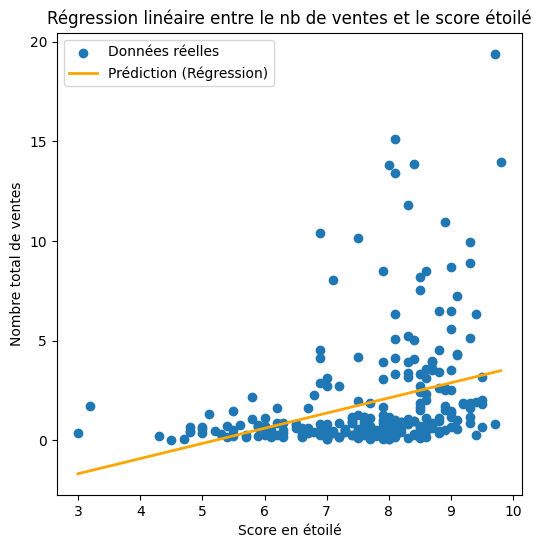

In [62]:
# Figure de base

X = pd.Series(data["critic_score"])
y = pd.Series(data["total_sales"])
plt.figure(figsize=(6, 6))
plt.scatter(X, y, label='Données réelles')

# Créer une séquence de X qui va du minimum au maximum des données
# reshape(-1, 1) est nécessaire pour scikit learn
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Prédiction
y_plot_pred = model.predict(X_plot)

plt.plot(X_plot, y_plot_pred, color='orange', linewidth=2, label='Prédiction (Régression)')
plt.title("Régression linéaire entre le nb de ventes et le score étoilé")
plt.xlabel("Score en étoilé")
plt.ylabel("Nombre total de ventes")
plt.legend()
plt.show()

## Sources

YouTube

- [Learn Pandas in 30 Minutes - Python Pandas Tutorial](https://www.youtube.com/watch?v=EXIgjIBu4EU)
- 